In [ ]:
from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0 # (Diemension, Row, Column, Channel) / 255.0(정규화)

train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size=0.2,
        random_state=42
    )

#### 합성곱(CNN)층 만들기

In [31]:
model = keras.Sequential()

In [32]:
model.add(
    keras.layers.Conv2D(
        32, # Filter의 갯수
        kernel_size=3, # 보통 정사각형으로 구성
        activation='relu', # 활성화 함수
        padding='same', #valid
        input_shape=(28,28,1)
    )
)

c:\Users\tjoeun\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### 풀링층

In [33]:
# Pooling
model.add(
    keras.layers.MaxPool2D(2) # 2*2 max pooling
)

#### 두번째 합성곱층

In [34]:
model.add(
    keras.layers.Conv2D(
        64, # Filter의 갯수
        kernel_size=3, # 보통 정사각형으로 구성
        activation='relu', # 활성화 함수
        padding='same' #valid
    )
)

# Pooling
model.add(
    keras.layers.MaxPool2D(2) # 2*2 max pooling
)

#### Dense층

In [35]:
# 입력층
model.add(
    keras.layers.Flatten()
)

#은닉층
model.add(
    keras.layers.Dense(
        100,
        activation='relu'
    )
)

# Dropout 층
model.add(
    keras.layers.Dropout(0.5)
)

# 출력층
model.add(
    keras.layers.Dense(
        10,
        activation='softmax'
    )
)

In [36]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

#### Model Complie

In [ ]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

choeckpoint_cb = keras.callbacks.ModelCheckpoint("../Data/best_model.keras")
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=2,
    restore_best_weights=True
)

In [38]:
history = model.fit(
    train_scaled,
    train_target,
    epochs = 20,
    validation_data =(val_scaled, val_target),
    callbacks = [choeckpoint_cb, early_stopping_cb]
    
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7909 - loss: 0.5842 - val_accuracy: 0.8705 - val_loss: 0.3517
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8594 - loss: 0.3893 - val_accuracy: 0.8931 - val_loss: 0.2932
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8777 - loss: 0.3368 - val_accuracy: 0.8999 - val_loss: 0.2720
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8903 - loss: 0.3056 - val_accuracy: 0.9054 - val_loss: 0.2540
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8980 - loss: 0.2822 - val_accuracy: 0.9148 - val_loss: 0.2330
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9057 - loss: 0.2582 - val_accuracy: 0.9177 - val_loss: 0.2274
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9107 - loss: 0.2445 - val_accuracy: 0.9166 - val_loss: 0.2240
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9189 - loss: 0

#### 평가와 예측

In [39]:
model.evaluate(train_scaled, train_target)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9449 - loss: 0.1493


[0.14930614829063416, 0.9448750019073486]

In [40]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9207 - loss: 0.2158


[0.2158314436674118, 0.9206666946411133]

#### 이미지로 확인하기

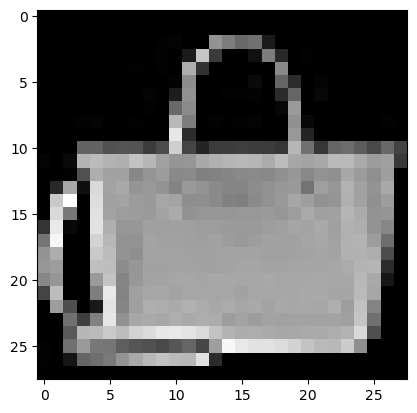

In [41]:
import matplotlib.pyplot as plt

plt.imshow(
    val_scaled[0].reshape(28, 28),
    cmap='gray'
)
plt.show()

In [42]:
pred = model.predict(
    val_scaled[:1]
)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


array([[2.0290674e-16, 3.6462371e-26, 1.6879903e-19, 5.6678059e-23,
        5.0968853e-19, 8.9227258e-17, 2.4692887e-16, 3.6852263e-17,
        1.0000000e+00, 1.4012953e-18]], dtype=float32)

In [43]:
# 글자로 변경하기
import numpy as np
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트', '샌달', '셔츠', '스니커즈', '가방', '앵글부츠']
len(classes)

10

In [44]:
classes[np.argmax(pred)]

'가방'

#### test data로 확인하기

In [45]:
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9114 - loss: 0.2475


[0.2474885731935501, 0.9114000201225281]